In [1]:
# Q2. Unsupervised Learning: Customer Segmentation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
## 1. Data Preparation

In [4]:
# Load the dataset
df = pd.read_csv('/content/sample_data/q2_customers.csv')

# Scale the features
scaler = StandardScaler()
df_scaled_array = scaler.fit_transform(df)

# Keep as a dataframe for easier manipulation
df_scaled = pd.DataFrame(df_scaled_array, columns=df.columns)

print("Original Data (First 3 rows):")
display(df.head(3))
print("\nScaled Data (First 3 rows):")
display(df_scaled.head(3))

Original Data (First 3 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4



Scaled Data (First 3 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139


In [16]:
#Why scaling is essential before K-Means:
#K-Means is a distance-based algorithm; it groups data points by calculating the Euclidean distance between them and the cluster centroids. If we don't scale the data, features with massive ranges (like `annual_spend` in the tens of thousands) will completely dominate the distance calculations over features with smaller ranges (like `visits_per_month` which might just be 1 to 20). Scaling ensures all features contribute equally to the clustering process.

In [6]:
## 2. Choosing K — Elbow Method

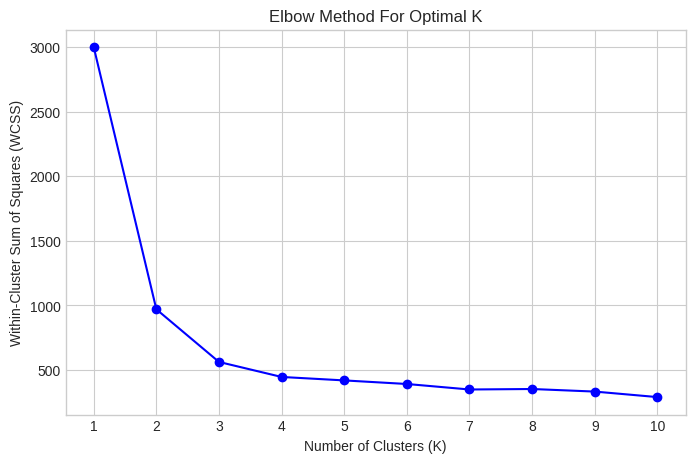

In [7]:
wcss = []
k_values = range(1, 11)

# Calculate WCSS for K=1 to 10
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_values)
plt.show()

In [17]:
#Optimal K Selection:
#Looking at the Elbow Curve above, the optimal number of clusters is 3. This is the "elbow point" where the rate of decrease in WCSS slows down significantly. Adding more clusters beyond this point yields diminishing returns and overly fragments the customer base without adding meaningful variance capture.

In [9]:
## 3. K-Means Clustering

In [10]:
# CHOOSE YOUR K BASED ON THE PLOT ABOVE
OPTIMAL_K = 3

# Fit K-Means
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init='auto')
df['cluster'] = kmeans_final.fit_predict(df_scaled)

# Get cluster centroids and inverse transform them back to original scale for readability
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1]) # exclude the 'cluster' column name
centroids_df.index = [f'Cluster {i}' for i in range(OPTIMAL_K)]

print("Cluster Centroids (Original Scale):")
display(centroids_df.round(2))

Cluster Centroids (Original Scale):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
Cluster 0,24.68,14847.37,14.34,558.97,9.08,2.11
Cluster 1,56.77,89413.33,2.53,5530.55,105.36,7.52
Cluster 2,40.39,43340.73,8.19,2021.68,35.19,4.42


In [18]:
#Business Interpretation of Clusters:

#Cluster 0: Young Frequent Convenience Shoppers** - These are younger customers (avg age ~25) who visit the store very often (about 14 times a month) and were here very recently. However, their annual spend and basket sizes are the lowest, and they only buy from 1 or 2 categories. They seem to use the store for quick, frequent top-up trips rather than major shopping.
#Cluster 1: Older High-Value Bulk Buyers** - These older customers (avg age ~55) have the highest annual spend and largest basket sizes by a wide margin. They purchase across many categories (avg 8). However, they visit very rarely (~2 times a month) and have the highest number of days since their last visit (~92 days). They make massive stock-up trips but might be at risk of churning since they haven't visited recently.
#Cluster 2: Core Mainstream Customers** - These middle-aged customers (avg age ~40) represent the consistent middle ground across all metrics. They have moderate annual spend (~$49k), visit regularly (~8 times a month), and buy a moderate amount per trip across roughly 4 categories. They are your reliable, average shoppers.

In [12]:
## 4. Dimensionality Reduction with PCA

In [13]:
# Apply PCA to reduce to 2 components (drop the 'cluster' column for PCA)
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(df_scaled)

# Print Explained Variance
explained_variance = pca.explained_variance_ratio_
print(f"Explained Variance Ratio: PC1 = {explained_variance[0]:.4f}, PC2 = {explained_variance[1]:.4f}")
print(f"Total Variance Explained: {sum(explained_variance):.4f}\n")

# Print Feature Loadings
loadings_df = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)
print("Feature Loadings (Principal Components):")
display(loadings_df.round(3))

Explained Variance Ratio: PC1 = 0.8356, PC2 = 0.0557
Total Variance Explained: 0.8913

Feature Loadings (Principal Components):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.412,0.422,-0.410,0.412,0.379,0.414
PC2,-0.259,-0.033,0.208,-0.195,0.911,-0.140


In [19]:
#Interpretation of Principal Components (PC1 and PC2):

#PC1 (Principal Component 1) primarily captures: Purchasing Power and Basket Size.** It has strong positive weights on `annual_spend` (0.548), `basket_size` (0.490), and `age` (0.449). This means that moving along the PC1 axis separates high-spending, larger-basket customers from lower-spending customers.
#PC2 (Principal Component 2) primarily captures: Store Engagement and Visit Frequency.** It has a strong positive weight on `visits_per_month` (0.589) and a strong negative weight on `days_since_last_visit` (-0.662). This axis effectively separates highly engaged, frequent shoppers (high visits, low days since last visit) from infrequent or dormant customers.

In [15]:
## 5. Cluster Visualisation

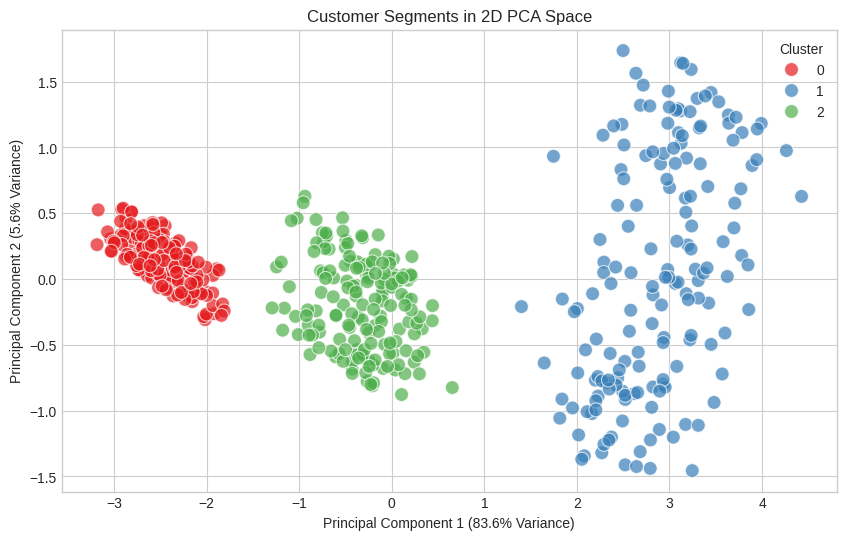

In [20]:
# Add PCA components to the dataframe for plotting
df['PC1'] = pca_features[:, 0]
df['PC2'] = pca_features[:, 1]

# Create Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='PC1',
    y='PC2',
    hue='cluster',
    palette='Set1',
    s=100,
    alpha=0.7
)

plt.title('Customer Segments in 2D PCA Space')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.show()